# Corrélation

L'objectif de cet exercice est de comprendre la notion d'incertitude et de corrélation dans les paramètres optimaux d'un ajustement. Ceci sont donnés par la deuxième sortie de la fonction ```curve_fit```. Cette sortie est une estimation de la matrice de covariance des paramètres estimés. Si on note $\theta$ le vecteur des paramètress, cette matrice représente $\left<(\theta_i - \left<\theta_i\right>)(\theta_j - \left<\theta_j\right>)\right>$. Les élements diagonaux sont donc la variance des paramètres.

On simule une jeu de données à l'aide du code suivant. On peut imaginer que cela représente la population de la france en million d'habitants au cours des dernières années. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0) # pour que le générateur "aléatoire" soit 
                  # le même pour tout le monde
N = 100
x = np.linspace(2005, 2026, N)
y = np.arange(N)*0.2 + 45 + np.random.normal(size=N)

1. Tracer et ajuster les données par une une droite $y = a x + b$.

2. Quelle est la signification "physique" de $b$ ? Quel est l’incertitude sur $b$? Qu’en pensez-vous ? 

3. Calculer la valeur et l’incertitude de votre fit en $x = 2010$. Pourquoi est-il important de tenir compte des corrélations.

4. Réaliser $M$ simulations ($M$ = 1000 par exemples) (c'est à dire que l'on effectuera $M$ tirage aléatoire et autant d'ajustement); tracer sur un graph les coefficients a et b; Calculez à l'aide de la fonction ```np.cov``` la matrice de covariance de ces simulations.

5. Trouvez une fonction de fit plus pertinente pour ce problème.

-------------------------------

## Solution

[ 9.28698730e-01 -1.81683248e+03]


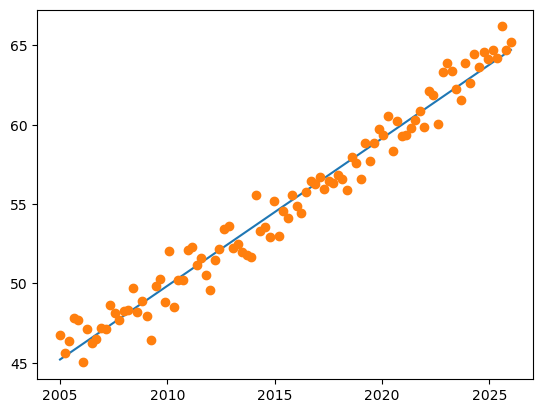

In [3]:
# Question 1
from scipy.optimize import curve_fit

def fit_function(x, a, b):
    return a*x + b

p_opt, cov_mat = curve_fit(fit_function, x, y)
a, b = p_opt
print(p_opt)
plt.plot(x,fit_function(x,*p_opt))
plt.plot(x,y,"o")

In [4]:
# Question 2

sigma = np.sqrt(np.diag(cov_mat))

sigma_a = sigma[0]
sigma_b = sigma[1]

print(f'Incertitude sur b : {sigma_b:.1f}')
# L'incertitude sur b est beaucoup plus importante que l'incertitude
# sur chaque point
# b est l'extrapolation il y a 2000 ans de la population et n'a pas de sens physique

Incertitude sur b : 33.4


In [5]:
# Question 3
x_test = 2010

print('Valeur en 2010 ', a*x_test + b)

sigma_y = np.sqrt(x_test**2 * sigma_a**2 + sigma_b**2)
print('Incertitude sans correlations', sigma_y)

Valeur en 2010  49.85196501378209
Incertitude sans correlations 47.154012351085996


Les variables $a$ et $b$ ne sont pas indépendante. La variance de $ax + b$ est donnée par $x^2\mathrm{Var}(a) + \mathrm{Var}(b) + 2x\mathrm{Covar}(a, b)$

In [6]:
sigma_y = np.sqrt(x_test**2 * sigma_a**2 + sigma_b**2 + 2*x_test*cov_mat[1, 0])
print(f'Incertitude avec correlations {sigma_y:.3f}')

Incertitude avec correlations 0.136


Il est donc important de tenir compte des correlations obtenu par le fit pour calculer exactement l'incertitude sur une valeur du fit.

In [6]:
# Question 4
def one_simulation():
    N = 100
    x = np.linspace(2000, 2018, N)
    y = np.arange(N)*0.2 + 45 + np.random.normal(size=N)
    p_opt, cor_mat = curve_fit(fit_function, x, y)
    return p_opt

M = 1000
many_results = np.array([one_simulation() for _ in range(M)])
Ta, Tb = many_results.T

Text(0, 0.5, 'b')

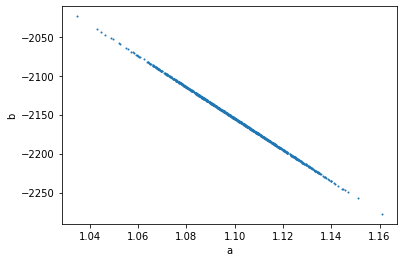

In [7]:
fig = plt.figure()
ax = fig.subplots(1, 1)

ax.scatter(Ta, Tb, s=1)
ax.set_xlabel('a')
ax.set_ylabel('b')

In [8]:
cov_numerique = np.cov(many_results.T)
print(cov_numerique)

[[ 3.47366872e-04 -6.97875508e-01]
 [-6.97875508e-01  1.40207350e+03]]


In [9]:
cov_mat

array([[ 3.73523915e-04, -7.50409536e-01],
       [-7.50409536e-01,  1.50758303e+03]])

In [10]:
# Fonction de fit plus pretinente
# Le parametre $b$ correspond au fit en l'an 2000
def fit_function(x, a, b):
    return a*(x-2000) + b

p_opt, cor_mat = curve_fit(fit_function, x, y)
a, b = p_opt

sigma = np.sqrt(np.diag(cor_mat))
sigma_a = sigma[0]
sigma_b = sigma[1]

x_test = 10

print('Valeur en 2010 ', a*x_test + b)

sigma_y = np.sqrt(x_test**2 * sigma_a**2 + sigma_b**2)
print('Incertitude sans correlations', sigma_y)

sigma_y = np.sqrt(x_test**2 * sigma_a**2 + sigma_b**2 + 2*x_test*cor_mat[1, 0])
print('Incertitude avec correlations', sigma_y)

Valeur en 2010  56.04328985689939
Incertitude sans correlations 0.2790998350851877
Incertitude avec correlations 0.10325894775854749
